# Bài tập: Dự đoán giá nhà California Housing bằng Multilayer Perceptron (MLP)
* **Họ tên:** [Điền họ tên của bạn]
* **MSSV:** [Điền MSSV của bạn]

Chúng ta sẽ sử dụng bộ dữ liệu `California Housing` từ `sklearn.datasets` để dự đoán giá nhà trung bình.

## 1. Thiết lập môi trường và Import thư viện

In [7]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.datasets import fetch_california_housing
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.preprocessing import PolynomialFeatures
from sklearn.pipeline import make_pipeline
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_error, r2_score

# Bỏ qua cảnh báo
import warnings
warnings.filterwarnings('ignore')


## 2. Tải và Khám phá dữ liệu (EDA)

,MedInc,HouseAge,AveRooms,AveBedrms,Population,AveOccup,Latitude,Longitude,MedHouseVal
0,8.3252,41.0,6.984127,1.023810,322.0,2.555556,37.88,-122.23,4.526
1,8.3014,21.0,6.238137,0.971880,2401.0,2.109842,37.86,-122.22,3.585
2,7.2574,52.0,8.288136,1.073446,496.0,2.802260,37.85,-122.24,3.521
3,5.6431,52.0,5.817352,1.073059,558.0,2.547945,37.85,-122.25,3.413
4,3.8462,52.0,6.281853,1.081081,565.0,2.181467,37.85,-122.25,3.422



--- THÔNG TIN DỮ LIỆU ---
<class 'pandas.DataFrame'>
RangeIndex: 20640 entries, 0 to 20639
Data columns (total 9 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   MedInc       20640 non-null  float64
 1   HouseAge     20640 non-null  float64
 2   AveRooms     20640 non-null  float64
 3   AveBedrms    20640 non-null  float64
 4   Population   20640 non-null  float64
 5   AveOccup     20640 non-null  float64
 6   Latitude     20640 non-null  float64
 7   Longitude    20640 non-null  float64
 8   MedHouseVal  20640 non-null  float64
dtypes: float64(9)
memory usage: 1.4 MB


,MedInc,HouseAge,AveRooms,AveBedrms,Population,AveOccup,Latitude,Longitude,MedHouseVal
count,20640.000000,20640.000000,20640.000000,20640.000000,20640.000000,20640.000000,20640.000000,20640.000000,20640.000000
mean,3.870671,28.639486,5.429000,1.096675,1425.476744,3.070655,35.631861,-119.569704,2.068558
std,1.899822,12.585558,2.474173,0.473911,1132.462122,10.386050,2.135952,2.003532,1.153956
min,0.499900,1.000000,0.846154,0.333333,3.000000,0.692308,32.540000,-124.350000,0.149990
25%,2.563400,18.000000,4.440716,1.006079,787.000000,2.429741,33.930000,-121.800000,1.196000
50%,3.534800,29.000000,5.229129,1.048780,1166.000000,2.818116,34.260000,-118.490000,1.797000
75%,4.743250,37.000000,6.052381,1.099526,1725.000000,3.282261,37.710000,-118.010000,2.647250
max,15.000100,52.000000,141.909091,34.066667,35682.000000,1243.333333,41.950000,-114.310000,5.000010


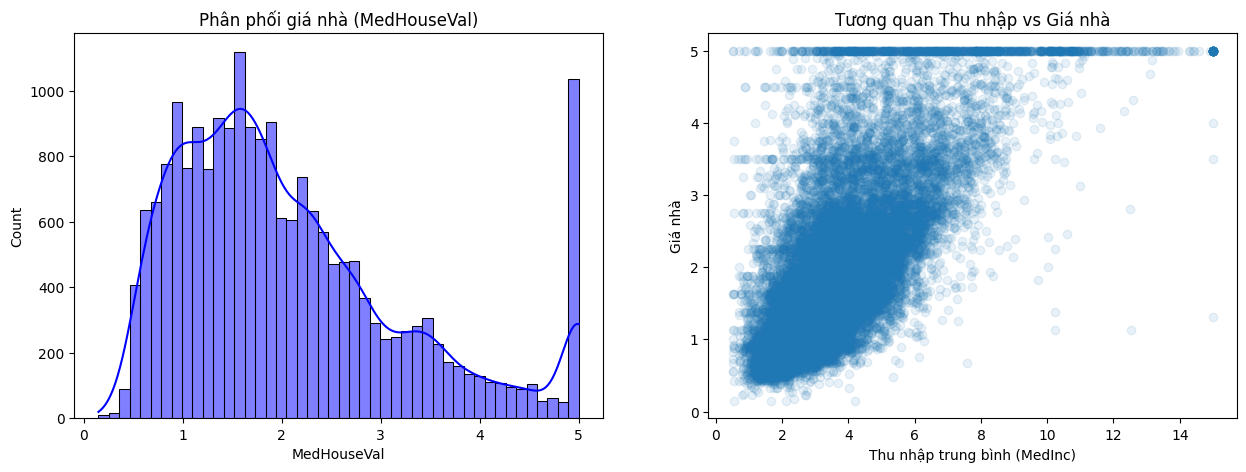

In [8]:
# Tải dữ liệu California Housing
housing = fetch_california_housing()
df = pd.DataFrame(housing.data, columns=housing.feature_names)
df['MedHouseVal'] = housing.target

# Xem 5 dòng đầu
display(df.head())

# Xem thông tin dữ liệu
print("\n--- THÔNG TIN DỮ LIỆU ---")
df.info()

# Thống kê cơ bản
display(df.describe())

# Trực quan hóa dữ liệu (EDA)
plt.figure(figsize=(15, 5))
plt.subplot(1, 2, 1)
sns.histplot(df['MedHouseVal'], kde=True, color='blue')
plt.title('Phân phối giá nhà (MedHouseVal)')

plt.subplot(1, 2, 2)
plt.scatter(df['MedInc'], df['MedHouseVal'], alpha=0.1)
plt.xlabel('Thu nhập trung bình (MedInc)')
plt.ylabel('Giá nhà')
plt.title('Tương quan Thu nhập vs Giá nhà')
plt.show()

## 3. Tiền xử lý dữ liệu (Preprocessing)

Dữ liệu California Housing không có giá trị missing, nên không cần xử lý missing values.
Chúng ta sẽ tách đặc trưng / nhãn, chia tập Train/Test, và chuẩn hóa dữ liệu.

In [9]:
# Tách đặc trưng (X) và nhãn dự đoán (y)
X = df.drop('MedHouseVal', axis=1).values
y = df['MedHouseVal'].values.reshape(-1, 1)

# Chia tập Train/Test (Tỷ lệ 80/20)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Chuẩn hóa dữ liệu (Z-score normalization)
mean = X_train.mean(axis=0)
std = X_train.std(axis=0)
X_train_scaled = (X_train - mean) / std
X_test_scaled = (X_test - mean) / std

print(f"Kích thước tập Train: {X_train_scaled.shape}")
print(f"Kích thước tập Test:  {X_test_scaled.shape}")

Kích thước tập Train: (16512, 8)
Kích thước tập Test:  (4128, 8)


## 4. Xây dựng và Huấn luyện mô hình

Tự triển khai mạng MLP (Multilayer Perceptron) từ đầu với kiến trúc:
- Input layer: 8 neurons (8 đặc trưng)
- Hidden layer 1: 64 neurons (ReLU)
- Hidden layer 2: 32 neurons (ReLU)
- Output layer: 1 neuron (Linear)

In [10]:
# Tự triển khai MLP từ đầu (Scratch)
class MLPScratch:
    def __init__(self, layers, lr=0.01):
        self.layers = layers
        self.lr = lr
        self.params = {}
        for i in range(len(layers) - 1):
            self.params[f'W{i+1}'] = np.random.randn(layers[i], layers[i+1]) * 0.1
            self.params[f'b{i+1}'] = np.zeros((1, layers[i+1]))

    def relu(self, Z): return np.maximum(0, Z)
    def relu_derivative(self, Z): return (Z > 0).astype(float)

    def forward(self, X):
        self.A0 = X
        self.Z1 = np.dot(self.A0, self.params['W1']) + self.params['b1']
        self.A1 = self.relu(self.Z1)
        self.Z2 = np.dot(self.A1, self.params['W2']) + self.params['b2']
        self.A2 = self.relu(self.Z2)
        self.Z3 = np.dot(self.A2, self.params['W3']) + self.params['b3']
        return self.Z3

    def train(self, X, y, epochs=100, batch_size=32):
        history = []
        for epoch in range(epochs):
            # Mini-batch gradient descent
            indices = np.random.permutation(X.shape[0])
            for i in range(0, X.shape[0], batch_size):
                idx = indices[i:i+batch_size]
                X_batch, y_batch = X[idx], y[idx]

                # Forward
                pred = self.forward(X_batch)

                # Backward
                dZ3 = pred - y_batch
                dW3 = np.dot(self.A2.T, dZ3) / batch_size
                db3 = np.sum(dZ3, axis=0, keepdims=True) / batch_size

                dZ2 = np.dot(dZ3, self.params['W3'].T) * self.relu_derivative(self.Z2)
                dW2 = np.dot(self.A1.T, dZ2) / batch_size
                db2 = np.sum(dZ2, axis=0, keepdims=True) / batch_size

                dZ1 = np.dot(dZ2, self.params['W2'].T) * self.relu_derivative(self.Z1)
                dW1 = np.dot(self.A0.T, dZ1) / batch_size
                db1 = np.sum(dZ1, axis=0, keepdims=True) / batch_size

                # Update
                for p in ['W1', 'b1', 'W2', 'b2', 'W3', 'b3']:
                    self.params[p] -= self.lr * eval(f'd{p}')

            loss = np.mean((self.forward(X) - y)**2)
            history.append(loss)
            if epoch % 10 == 0: print(f'Epoch {epoch}: Loss {loss:.4f}')
        return history

# Khởi tạo và huấn luyện mô hình MLP
mlp = MLPScratch(layers=[8, 64, 32, 1], lr=0.001)
history_scratch = mlp.train(X_train_scaled, y_train, epochs=100)
print("Huấn luyện xong!")

Epoch 0: Loss 1.7974
Epoch 10: Loss 0.5673
Epoch 20: Loss 0.4859
Epoch 30: Loss 0.4468
Epoch 40: Loss 0.4264
Epoch 50: Loss 0.4126
Epoch 60: Loss 0.4019
Epoch 70: Loss 0.3927
Epoch 80: Loss 0.3844
Epoch 90: Loss 0.3770
Huấn luyện xong!


## 5. Dự đoán và Đánh giá kết quả

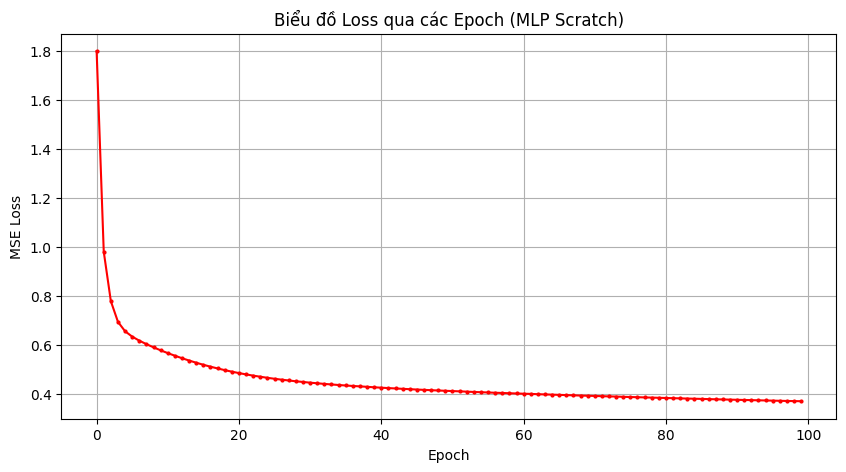

MSE của MLP Scratch: 0.3845


In [11]:
# Biểu đồ Loss qua các Epoch
plt.figure(figsize=(10, 5))
plt.plot(history_scratch, color='red', marker='o', markersize=2)
plt.title('Biểu đồ Loss qua các Epoch (MLP Scratch)')
plt.xlabel('Epoch')
plt.ylabel('MSE Loss')
plt.grid(True)
plt.show()

# Đánh giá trên tập Test
y_pred = mlp.forward(X_test_scaled)
mse = np.mean((y_test - y_pred)**2)
print(f"MSE của MLP Scratch: {mse:.4f}")

## 6. So sánh với các mô hình khác

So sánh hiệu suất MLP (Scratch) với Linear Regression và Random Forest.


BẢNG SO SÁNH CÁC MÔ HÌNH DỰ ĐOÁN GIÁ NHÀ:


,Model,MSE,R2 Score
0,MLP (Scratch),0.384479,0.706596
1,Linear Regression,0.555892,0.575788
2,Polynomial Regression (bậc 2),0.464302,0.645682
3,Random Forest,0.255170,0.805275


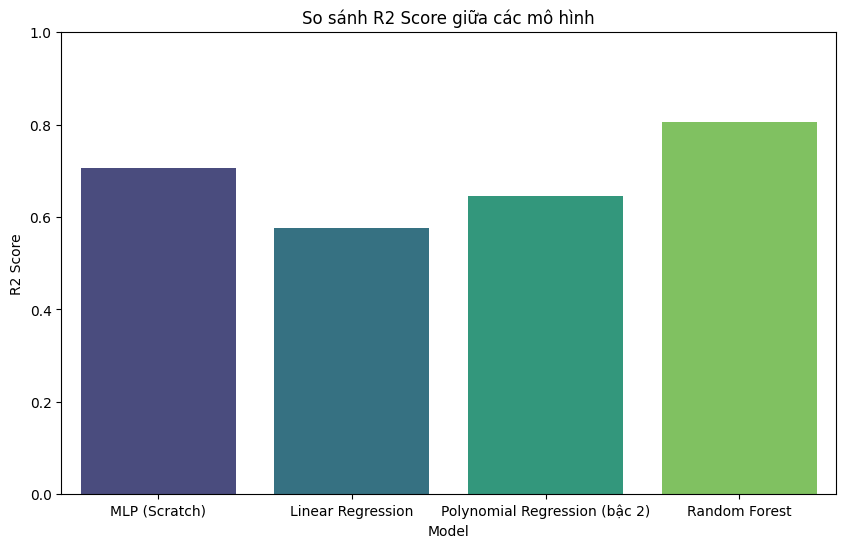

In [12]:
# Linear Regression
lr = LinearRegression()
lr.fit(X_train_scaled, y_train.ravel())
y_pred_lr = lr.predict(X_test_scaled)

# Hồi quy đa thức (Polynomial Regression bậc 2)
poly_reg = make_pipeline(PolynomialFeatures(degree=2), LinearRegression())
poly_reg.fit(X_train_scaled, y_train.ravel())
y_pred_poly = poly_reg.predict(X_test_scaled)

# Random Forest
rf = RandomForestRegressor(n_estimators=100, random_state=42)
rf.fit(X_train_scaled, y_train.ravel())
y_pred_rf = rf.predict(X_test_scaled)

# Dự đoán từ MLP Scratch
y_pred_scratch = mlp.forward(X_test_scaled).flatten()

# Tổng hợp kết quả
results = pd.DataFrame({
    'Model': ['MLP (Scratch)', 'Linear Regression', 'Polynomial Regression (bậc 2)', 'Random Forest'],
    'MSE': [
        mean_squared_error(y_test, y_pred_scratch),
        mean_squared_error(y_test, y_pred_lr),
        mean_squared_error(y_test, y_pred_poly),
        mean_squared_error(y_test, y_pred_rf)
    ],
    'R2 Score': [
        r2_score(y_test, y_pred_scratch),
        r2_score(y_test, y_pred_lr),
        r2_score(y_test, y_pred_poly),
        r2_score(y_test, y_pred_rf)
    ]
})

print("\nBẢNG SO SÁNH CÁC MÔ HÌNH DỰ ĐOÁN GIÁ NHÀ:")
display(results)

# Trực quan hóa so sánh
plt.figure(figsize=(10, 6))
sns.barplot(x='Model', y='R2 Score', data=results, palette='viridis', hue='Model', legend=False)
plt.title('So sánh R2 Score giữa các mô hình')
plt.ylim(0, 1)
plt.show()
